# Subsidy capitalisation in a migration model

**Research question.** How large a subsidy must a state offer residents to sustain net in-migration once rent feedback is accounted for, and how does this depend on housing supply elasticity? The policy state is Ohio.

**Status: work in progress.** Parameters are placeholders and have not been calibrated. Money is in $k per year.

**Contents**

1. Introduction and setup
2. Data
3. Model
4. Validation (baseline run, comparison with observed migration, unit tests)
5. Experiments
6. Results *(to be completed)*
7. Discussion and limitations *(to be completed)*
8. Interactive demonstration *(to be completed)*

## 1. Introduction and setup

When people move into a state, demand for housing rises and so does rent. A state that subsidises residents to attract them may therefore see part of the subsidy absorbed by higher rent (capitalisation). The model below represents individual agents choosing among 8 U.S. states, with rent responding to population through a housing supply elasticity, and uses it to study how large a subsidy is needed and how this depends on housing supply.

This differs from Schelling-style models, in which agents move in response to their neighbours and nothing else changes. Here agents respond to prices that their own collective movement changes.

In [1]:
import sys, subprocess
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.model import MigrationModel
from src.params import Params
from utils.data import load_initial_state
from utils.metrics import simulated_net_migration_per_1000, observed_net_migration_per_1000

## 2. Data

Real 2010 state data initialises the model. Observed migration is held back and used only to check the baseline.

### 2.1 (Optional) Re-download the data

The CSV files in `data/` are already included, so **this step is not needed to run the notebook**. To regenerate them from the U.S. Census API, get a free key from <https://api.census.gov/data/key_signup.html>, save it in a `.env` file in the project root as `CENSUS_API_KEY=<your key>`, set `REFRESH_DATA = True` below and run the cell.

In [2]:
REFRESH_DATA = False

if REFRESH_DATA:
    subprocess.run([sys.executable, "-m", "utils.fetch_census"], cwd=ROOT, check=True)
else:
    print("Skipping download; using the CSV files already in data/.")

Skipping download; using the CSV files already in data/.


### 2.2 Initial conditions

Eight states chosen to contrast growth and housing costs. Population is used only to allocate agents to states in proportion; rent and income are 2010 ACS medians converted to $k per year.

In [3]:
init = load_initial_state(ROOT / "data" / "initial_state_2010.csv")
pd.DataFrame({"population": init.population, "rent ($k/yr)": init.rent, "income ($k/yr)": init.wage},
             index=init.names).round(1)

,population,rent ($k/yr),income ($k/yr)
California,37349363.0,14.0,57.7
New York,19392283.0,12.2,54.1
Illinois,12843166.0,10.2,53.0
Ohio,11536182.0,8.2,45.1
Texas,25257114.0,9.6,48.6
Florida,18843326.0,11.4,44.4
Colorado,5049071.0,10.4,54.0
North Carolina,9561558.0,8.8,43.3


## 3. Model

Each year a random fraction of the $N$ agents reconsider where to live. Agent $i$ with income multiplier $z_i$ values state $j$ at

$$u_{ij} = z_i\, w_j - r_j + s_j + \tau\, \frac{n_j}{N} - c\,\mathbf{1}[j \ne \text{current state}]$$

where $w_j$ is the state wage, $r_j$ rent, $s_j$ the subsidy (non-zero only in the policy state), $n_j/N$ the state's population share (social ties, strength $\tau$) and $c$ the migration cost. The agent picks state $j$ with probability $\propto e^{\beta u_{ij}}$.

After everyone has chosen, rent responds to the population change with housing supply elasticity $\varepsilon$:

$$r_j^{t+1} = r_j^{t}\left(\frac{n_j^{t+1}}{n_j^{t}}\right)^{1/\varepsilon}$$

A low $\varepsilon$ means rent rises sharply when people move in, so part of any subsidy is absorbed by rent (capitalisation).

## 4. Validation

### 4.1 A single baseline run (no subsidy)

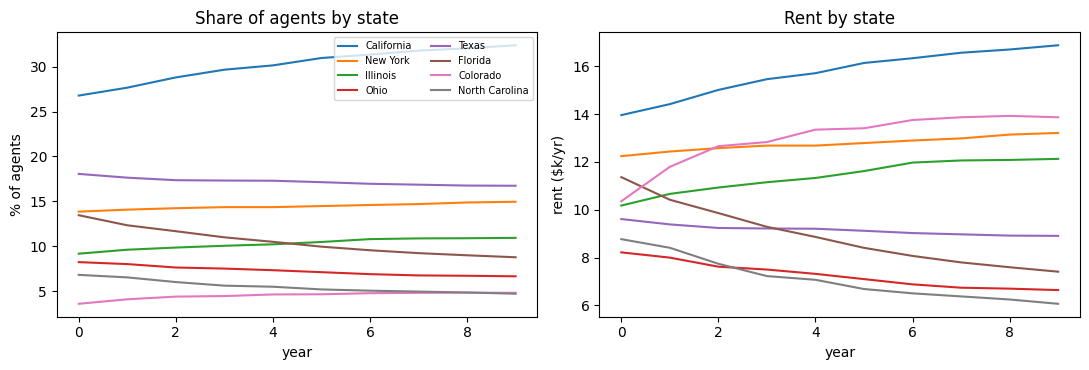

In [4]:
params = Params(n_years=9, seed=0)
h = MigrationModel(params, init).run()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
share = h.population / h.population.sum(axis=1, keepdims=True) * 100
for j, name in enumerate(init.names):
    ax[0].plot(share[:, j], label=name)
    ax[1].plot(h.rent[:, j])
ax[0].set(title="Share of agents by state", xlabel="year", ylabel="% of agents")
ax[1].set(title="Rent by state", xlabel="year", ylabel="rent ($k/yr)")
ax[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### 4.2 Baseline check against observed migration

We compare the simulated cumulative net migration (per 1,000 residents, averaged over 10 seeds, 9 years to match 2010-11 to 2018-19) with the observed net domestic migration. The observed data is *not* used to set up the model. Only the ranking and direction are meaningful, since the simulated system is closed (migration sums to zero across states).

In [5]:
obs = observed_net_migration_per_1000(ROOT / "data" / "observed_net_migration.csv", init)
sim = np.mean([simulated_net_migration_per_1000(
    MigrationModel(replace(params, seed=s), init).run(), params.n_agents) for s in range(10)], axis=0)

cmp = pd.DataFrame({"observed per 1000": obs, "simulated per 1000": sim}, index=init.names).round(1)
print("Spearman rank correlation:", round(cmp.corr(method="spearman").iloc[0, 1], 2))
cmp

Spearman rank correlation: -0.64


,observed per 1000,simulated per 1000
California,-23.9,57.4
New York,-70.0,13.2
Illinois,-66.4,16.7
Ohio,-18.1,-16.8
Texas,44.2,-15.2
Florida,67.9,-46.7
Colorado,68.5,13.0
North Carolina,47.6,-21.6


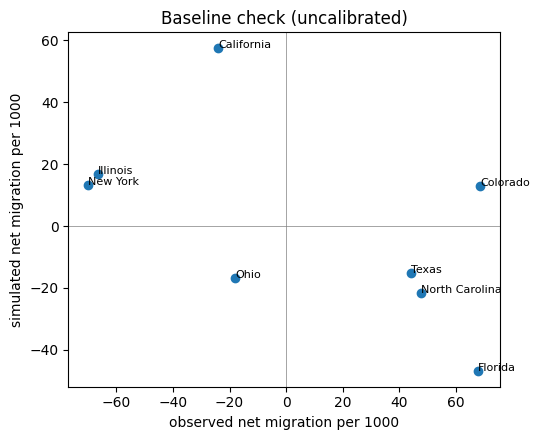

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(cmp["observed per 1000"], cmp["simulated per 1000"])
for name, row in cmp.iterrows():
    ax.annotate(name, (row["observed per 1000"], row["simulated per 1000"]), fontsize=8)
ax.axhline(0, c="grey", lw=.5); ax.axvline(0, c="grey", lw=.5)
ax.set(xlabel="observed net migration per 1000", ylabel="simulated net migration per 1000",
       title="Baseline check (uncalibrated)")
plt.tight_layout(); plt.show()

**Reading this.** With placeholder parameters the baseline does *not* reproduce the real pattern: states with high income net of rent (California, Colorado) attract agents in the model, whereas in reality the Sun Belt states gained and California, New York and Illinois lost. The model only contains wages, rent and ties, and omits other drivers such as jobs growth, climate and taxes. This is an honest limitation of the current version and a point for the next iteration.

### 4.3 Unit tests

The unit tests (conservation of agents, boundary cases, expected directions of effect) run with pytest.

In [7]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT, capture_output=True, text=True)
print(r.stdout[-600:])

## 5. Experiments

### 5.1 Outcome measures

Every measure compares a run **with** the subsidy against a **control run with no subsidy at the same elasticity**, using the same random seeds (20 seeds, 20 years). Ohio shrinks even without a subsidy, so raw populations would mislead.

- **Population gain** $G$: the extra Ohio population at year $T$ caused by the subsidy, as a fraction of Ohio's initial population (0.10 = +10%).
- **Capitalisation share** $\kappa = (\bar r_{\text{subsidy}} - \bar r_{\text{control}})/s$: the fraction of the subsidy absorbed by higher rent at year $T$ (both in $k/yr).
- **Required subsidy** $s^*$: the smallest subsidy giving $G \ge$ a target (here +10%), found by bisection.

These are measured at a **fixed horizon** ($T = 20$) and not at a "settled" state, because with elastic housing supply the system does not settle: rent barely responds, so the population keeps drifting. `settling_change` reports how much the population was still changing over the last 5 years.

In [8]:
from utils.experiments import run_ensemble, required_subsidy_for_target
from utils.metrics import population_gain, capitalisation_share, settling_change

ohio = init.index("Ohio")
T, N_SEEDS, TARGET = 20, 20, 0.10
elasticities = [0.3, 0.5, 1, 2, 4, 8]

rows = []
for eps in elasticities:
    base = Params(n_years=T, elasticity=eps, policy_state=ohio)
    control = run_ensemble(base, init, N_SEEDS)
    for s in (2, 5, 10):
        treated = run_ensemble(replace(base, subsidy=s), init, N_SEEDS)
        rows.append({"elasticity": eps, "subsidy ($k/yr)": s,
                     "gain G": population_gain(treated, control, ohio, T),
                     "capitalisation share": capitalisation_share(treated, control, ohio, s, T),
                     "still drifting (control, last 5y)": settling_change(control, ohio)})
measures = pd.DataFrame(rows)
measures.round(2)

,elasticity,subsidy ($k/yr),gain G,capitalisation share,"still drifting (control, last 5y)"
0,0.3,2,0.07,0.85,0.00
1,0.3,5,0.16,0.88,0.00
2,0.3,10,0.29,0.91,0.00
3,0.5,2,0.10,0.78,0.00
4,0.5,5,0.25,0.82,0.00
5,0.5,10,0.48,0.86,0.00
6,1.0,2,0.15,0.61,-0.03
7,1.0,5,0.40,0.66,-0.03
8,1.0,10,0.90,0.74,-0.03
9,2.0,2,0.18,0.44,-0.06


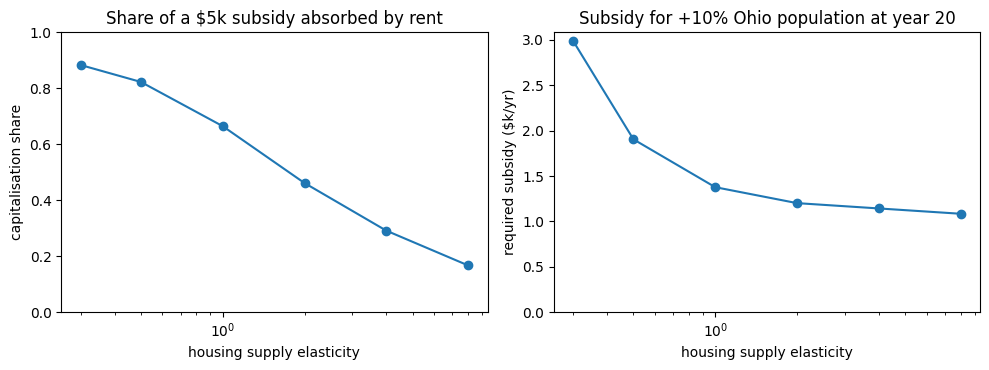

,required subsidy s* ($k/yr)
0.3,2.99
0.5,1.90
1.0,1.38
2.0,1.20
4.0,1.14
8.0,1.08


In [9]:
req = pd.Series({eps: required_subsidy_for_target(Params(n_years=T, elasticity=eps, policy_state=ohio),
                                                  init, TARGET, T, n_seeds=N_SEEDS)
                 for eps in elasticities}, name="required subsidy s* ($k/yr)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
kappa5 = measures[measures["subsidy ($k/yr)"] == 5]
ax[0].plot(kappa5["elasticity"], kappa5["capitalisation share"], "o-")
ax[0].set(xscale="log", xlabel="housing supply elasticity", ylabel="capitalisation share",
          title="Share of a $5k subsidy absorbed by rent", ylim=(0, 1))
ax[1].plot(req.index, req.values, "o-")
ax[1].set(xscale="log", xlabel="housing supply elasticity", ylabel="required subsidy ($k/yr)",
          title=f"Subsidy for +{TARGET:.0%} Ohio population at year {T}", ylim=(0, None))
plt.tight_layout(); plt.show()
req.round(2).to_frame()

**Reading this (placeholder parameters, so the direction matters more than the sizes).** The more inelastic the housing supply, the larger the share of a subsidy that rent absorbs and the smaller the population gain, so a larger subsidy is needed for the same target. The required subsidy falls steeply as $\varepsilon$ rises from 0.3 to about 2 and then flattens. The target is a modest +10%, and results at a different horizon or target will differ, which the full sweep will examine.

### 5.2 Experimental design

All experiments use Ohio as the policy state, a 20-year horizon and 20 random seeds per scenario, with the subsidy run and its no-subsidy control sharing seeds. Parameters not being varied keep the defaults in `src/params.py`. The configuration lives in `utils/run_sweeps.py`, results are cached as CSV files in `data/results/`, and set `RECOMPUTE = True` below to regenerate them (about 3 minutes).

| Experiment | What varies | Outcome |
|---|---|---|
| Main grid | elasticity (10 values, 0.3 to 8) $\times$ subsidy (9 values, 1 to 12 $k/yr) | gain $G$ (with standard error) and capitalisation share $\kappa$ |
| Required subsidy | elasticity $\times$ target gain (+5%, +10%, +20%) | $s^*$, repeated over 5 independent seed batches to show simulation noise |
| Sensitivity | migration cost, tie strength, choice sensitivity $\beta$, share reconsidering each year, and horizon (10, 20, 40 years), each across 6 elasticities | $s^*$ for the +10% target |

Migration cost and tie strength are two of the four manipulated parameters. $\beta$ and the share reconsidering are fixed constants whose placeholder values are included in the sensitivity analysis because they are not yet justified.

In [10]:
from utils.run_sweeps import compute_all
from utils import plots

RECOMPUTE = False   # set True to rerun every experiment (about 3 minutes)
results = compute_all(recompute=RECOMPUTE, verbose=False)
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(exist_ok=True)
{name: len(df) for name, df in results.items()}

{'gain_kappa_grid': 90,
 'required_subsidy': 30,
 'sensitivity_migration_cost': 30,
 'sensitivity_tie_strength': 30,
 'sensitivity_beta': 18,
 'sensitivity_move_fraction': 18,
 'sensitivity_horizon': 18}

## 6. Results

### 6.1 Population gain and capitalisation share

Both measures are taken at year 20 relative to the no-subsidy control. Across the grid, the gain ranges from 0.04 to 4.05 times Ohio's initial population, with standard errors of at most 0.02.

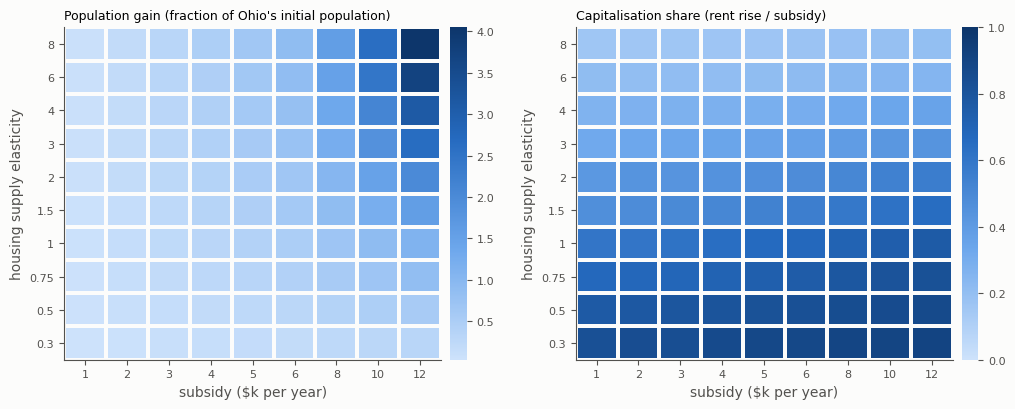

In [11]:
plots.plot_gain_kappa(results["gain_kappa_grid"], FIG / "gain_kappa.png");

The capitalisation share falls steadily as housing supply becomes more elastic, from about 0.9 at $\varepsilon = 0.3$ (most of the subsidy absorbed by rent) to about 0.2 at $\varepsilon = 8$. The population gain moves the opposite way and grows faster than linearly with the subsidy: at $\varepsilon = 8$ it rises from about 0.1 at a subsidy of 1 to about 4 at a subsidy of 12. At low elasticity the share is high and almost independent of the subsidy level.

### 6.2 Subsidy required for a target gain

,+5% target,+10% target,+20% target
elasticity,,,
0.30,1.42,2.97,6.52
0.50,0.97,1.95,3.93
0.75,0.80,1.56,3.04
1.00,0.73,1.42,2.71
1.50,0.65,1.27,2.44
2.00,0.61,1.18,2.24
3.00,0.60,1.15,2.13
4.00,0.55,1.11,2.07
6.00,0.57,1.07,2.04


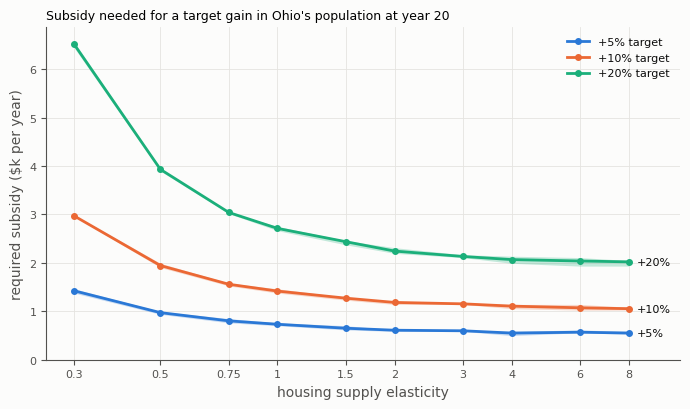

In [12]:
plots.plot_required_subsidy(results["required_subsidy"], FIG / "required_subsidy.png")
tbl = results["required_subsidy"].pivot(index="elasticity", columns="target", values="s_mean").round(2)
tbl.columns = [f"+{t:.0%} target" for t in tbl.columns]
tbl

The required subsidy falls steeply as supply becomes more elastic and then flattens. For the +10% target it drops from about 3.0 at $\varepsilon = 0.3$ to 1.2 at $\varepsilon = 2$, but only to 1.05 at $\varepsilon = 8$. The shaded bands show the spread over five independent seed batches, which is small (at most about 0.2, and usually much less), and beyond $\varepsilon \approx 3$ the differences between elasticities are within that noise. Most of the benefit of more elastic housing supply therefore arrives early. The required subsidy grows roughly in proportion to the target: at $\varepsilon = 1$ the three targets need about 0.7, 1.4 and 2.7. The absolute values (about 1 to 3 $k per year, against a median Ohio household income of about $45k) depend on placeholder parameters, as the next section shows.

### 6.3 Sensitivity to other parameters

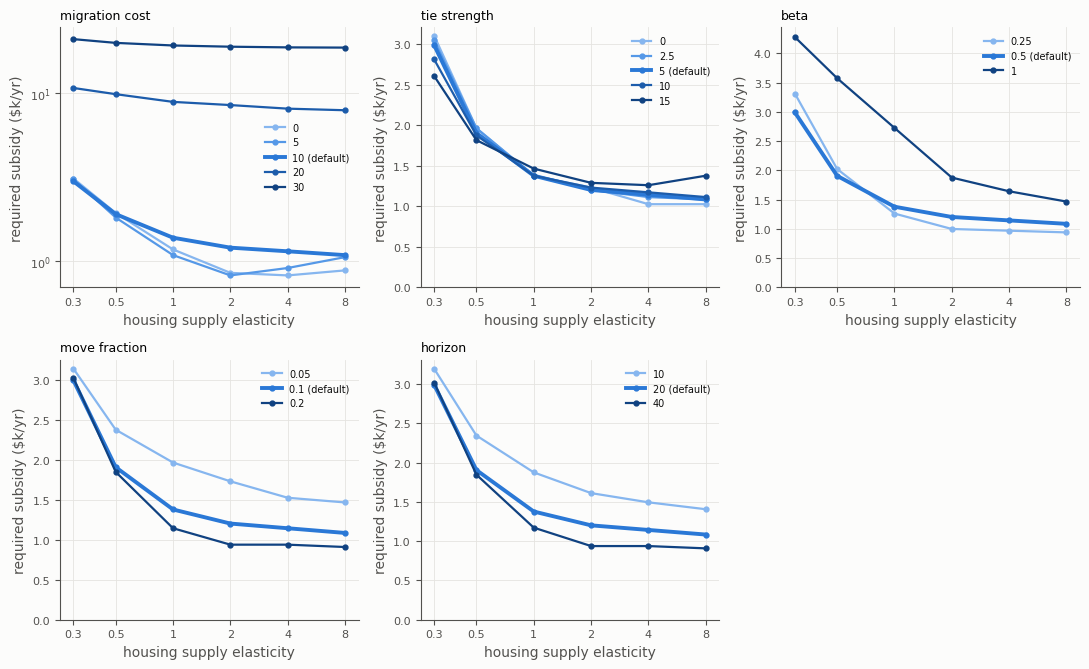

In [13]:
from utils.run_sweeps import SENSITIVITY
names = ["migration_cost", "tie_strength", "beta", "move_fraction", "horizon"]
tables = {n: results[f"sensitivity_{n}"] for n in names}
defaults = {"migration_cost": Params().migration_cost, "tie_strength": Params().tie_strength,
            "beta": Params().beta, "move_fraction": Params().move_fraction, "horizon": 20}
plots.plot_sensitivity(tables, defaults, save_path=FIG / "sensitivity.png");

Two findings stand out.

**The shape is mostly robust, but the size is not.** In every panel the required subsidy falls as elasticity rises, so the main qualitative result survives. The absolute level, however, depends strongly on migration cost (note the log axis in that panel: a cost of 20 raises the required subsidy to about 8 to 11, and a cost of 30 to about 19 to 21), on $\beta$, and on the share of agents reconsidering each year. The horizon matters at moderate and high elasticity: compared with 20 years, a 40-year horizon needs about 15 to 22% less subsidy and a 10-year horizon about 30 to 36% more, while at low elasticity ($\varepsilon \le 0.5$) the horizon makes little difference. The ordering across elasticities is the same at every horizon.

**Migration cost changes how much elasticity matters.** At high migration cost the subsidy mostly has to pay for the move itself, so elasticity makes little difference in absolute terms (about 10.8 down to 7.9 at a cost of 20, compared with 3.0 down to 1.1 at the default cost of 10).

**Unexplained behaviour.** At low migration cost (0 or 5) and, to a lesser extent, at the highest tie strength (15), the curve turns upward at high elasticity instead of flattening (for example 0.82 at $\varepsilon = 2$ rising to 1.05 at $\varepsilon = 8$ for a cost of 5). This is larger than the batch-to-batch noise (about 0.05). A possible explanation, not yet tested, is that the no-subsidy control run itself shrinks much more at high elasticity, which changes what the gain is measured against. This needs investigating before the report states the shape conclusion without qualification.

## 7. Discussion and limitations

*To be completed.* Points to cover: the uncalibrated baseline does not reproduce observed migration (section 4.2), which is treated as a stated limitation; results are scenario comparisons rather than forecasts; wages are fixed and housing supply is a single elasticity parameter; agents are generic residents with no age or education, and household-level medians stand in for all of them. Details are tracked in `report.md`.

## 8. Interactive demonstration

*To be completed.* Sliders for subsidy and elasticity with live plots, and an animation of flows between states.